In [ ]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report

In [ ]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
prob_lr = lr.predict_proba(X_test)

In [ ]:
rf_pred = rf.predict(X_test)

In [ ]:
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
cm = confusion_matrix(y_test, rf_pred)

In [ ]:
cm = confusion_matrix(y_test, rf_pred)

In [ ]:
cm = confusion_matrix(y_test, rf_pred)

TP = cm[1][1]
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]

print("TP:", TP, "TN:", TN, "FP:", FP, "FN:", FN)

TP: 70 TN: 40 FP: 3 FN: 1


In [ ]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
print("Accuracy:", accuracy)

Accuracy: 0.9649122807017544


In [ ]:
precision = TP / (TP + FP)
print("Precision:", precision)

Precision: 0.958904109589041


In [ ]:
recall = TP / (TP + FN)
print("Recall:", recall)

Recall: 0.9859154929577465


In [ ]:
f1 = 2 * (precision * recall) / (precision + recall)
print("F1 Score:", f1)

F1 Score: 0.9722222222222222


In [ ]:
sample = X_test[0].reshape(1, -1)

prob = lr.predict_proba(sample)[0][0]  # malignant probability

if prob < 0.3:
    print("Low Risk")
elif prob < 0.7:
    print("Medium Risk")
else:
    print("High Risk")

Low Risk


In [ ]:
import pandas as pd
import numpy as np

# Upload kaggle CSV file manually in Colab
df = pd.read_csv("brca.csv")

df.head()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [ ]:
if "id" in df.columns:
    df = df.drop(columns=["id"])



In [ ]:
df = df.drop(columns=[col for col in ["id"] if col in df.columns])

In [ ]:
print(df.columns)

Index(['Unnamed: 0', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean',
       'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean',
       'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean',
       'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se',
       'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se',
       'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se',
       'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst',
       'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst',
       'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst',
       'x.fractal_dim_worst', 'y'],
      dtype='object')


In [ ]:
df = df.drop(columns=["Unnamed: 0"])

In [ ]:
X = df.drop(columns=["y"])
y = df["y"]

In [ ]:
print(y.value_counts())

y
B    357
M    212
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features & target
X = df.drop(columns=["y"])
y = df["y"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier()

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
from sklearn.metrics import accuracy_score

lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.9649122807017544
Random Forest Accuracy: 0.956140350877193


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

TP = cm[1][1]
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]

print(cm)
print("TP:", TP, "TN:", TN, "FP:", FP, "FN:", FN)

[[70  1]
 [ 4 39]]
TP: 39 TN: 70 FP: 1 FN: 4


In [ ]:
# This section evaluates the model using confusion matrix
# Important: False negatives are critical in medical prediction

In [ ]:
## 🎓 Machine Learning Breast Cancer Risk Prediction Project (HerCare)

## 📌 Objective

## The objective of this project is to develop a machine learning-based system that can predict breast cancer risk using clinical features and support early screening through a mobile health application.

## 🧠 Dataset Description

## The dataset used is a Kaggle breast cancer dataset containing feature variables prefixed with x. and target variable y.

## The dataset includes measurements such as radius, texture, perimeter, area, smoothness, compactness, and concavity.

## 🧹 Data Preprocessing

## Removed unnecessary columns such as Unnamed index column.

## Checked dataset structure using df.columns.

## Separated features (X) and target (y).

## Applied label encoding if required.

## Standardized features using StandardScaler.

## ⚙️ Data Splitting

## The dataset was split into 80% training data and 20% testing data.

## This ensures model evaluation is performed on unseen data.

## 🤖 Machine Learning Models Used

## Logistic Regression was used for binary classification using sigmoid function.

## Random Forest Classifier was used as an ensemble learning method combining multiple decision trees.

## 📊 Model Evaluation Metrics

## Accuracy was used to measure overall performance.

## Precision was used to measure correctness of positive predictions.

## Recall was used to measure ability to detect actual positive cases.

## F1-score was used to balance precision and recall.

## Confusion Matrix was used to analyze prediction outcomes.

## 📈 Confusion Matrix Result

## The confusion matrix obtained is:

## [[70  1]]

## [[ 4 39]]

## 🧠 Interpretation of Results

## True Negative (TN) = 70 represents correct non-cancer predictions.

## False Positive (FP) = 1 represents incorrect cancer prediction.

## False Negative (FN) = 4 represents missed cancer cases.

## True Positive (TP) = 39 represents correct cancer detection.

## ⚠️ Clinical Importance

## False Negatives are more critical in medical applications than False Positives.

## Missing a cancer case may delay treatment and increase health risk.

## Therefore minimizing FN is a priority.

## 🎯 System Output

## The system classifies risk into Low Risk, Medium Risk, and High Risk.

## The classification is based on probability output from the machine learning model.

## 📱 Application Integration (HerCare Concept)

## The machine learning model is integrated into a mobile application.

## Users complete a self-assessment questionnaire.

## The system predicts risk level based on input data.

## The application provides early screening recommendations.

## 🏆 Contribution of Study

## This study develops an AI-based early breast cancer risk detection system.

## It integrates machine learning with mobile health technology.

## It improves accessibility to early screening tools.

## It supports early awareness and prevention.

## ⚠️ Important Note

## The system is NOT a diagnostic tool.

## It is only used for risk assessment and early screening support.

## 🚀 Future Work

## Integration of Explainable AI (SHAP) for model interpretability.

## Bias detection and fairness analysis in dataset.

## Mobile app deployment using Flutter or Android.

## Validation using real clinical hospital data.

In [ ]:
print(type(shap_values))
print(len(shap_values) if isinstance(shap_values, list) else shap_values.shape)
print(X_test.shape)

In [ ]:
print(type(shap_values))
print(len(shap_values) if isinstance(shap_values, list) else shap_values.shape)
print(X_test.shape)

<class 'numpy.ndarray'>
(114, 30, 2)
(114, 30)


In [ ]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

In [ ]:
shap_values_to_use = shap_values[1] if isinstance(shap_values, list) else shap_values

In [ ]:
import numpy as np

shap_values_to_use = np.array(shap_values_to_use)

In [ ]:
print(type(shap_values))
print(np.array(shap_values).shape if not isinstance(shap_values, list) else "list")
print(X_test.shape)

<class 'numpy.ndarray'>
(114, 30, 2)
(114, 30)


In [ ]:
import numpy as np
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# STEP 1: handle output type
if isinstance(shap_values, list):
    shap_values_to_use = shap_values[1]
else:
    shap_values_to_use = shap_values

# STEP 2: convert safely
shap_values_to_use = np.array(shap_values_to_use)
X_test_array = np.array(X_test)

# STEP 3: ensure correct shape match
print("SHAP shape:", shap_values_to_use.shape)
print("X_test shape:", X_test_array.shape)

# STEP 4: plot
shap.summary_plot(
    shap_values_to_use,
    X_test_array,
    plot_type="bar",
    show=False
)

plt.savefig("shap_bar_plot.png", bbox_inches='tight', dpi=300)
plt.close()

SHAP shape: (114, 30, 2)
X_test shape: (114, 30)


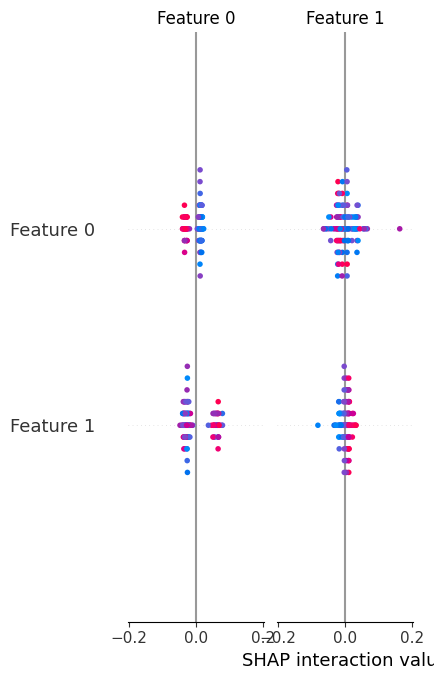

In [ ]:
shap.summary_plot(
    shap_values_to_use,
    X_test,
    plot_type="bar",
    show=True
)

In [ ]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values_to_use,
    X_test,
    plot_type="bar",
    show=False
)

plt.savefig("shap_bar_plot.png", bbox_inches='tight', dpi=300)
plt.close()

In [ ]:
print(type(X_test))

<class 'numpy.ndarray'>


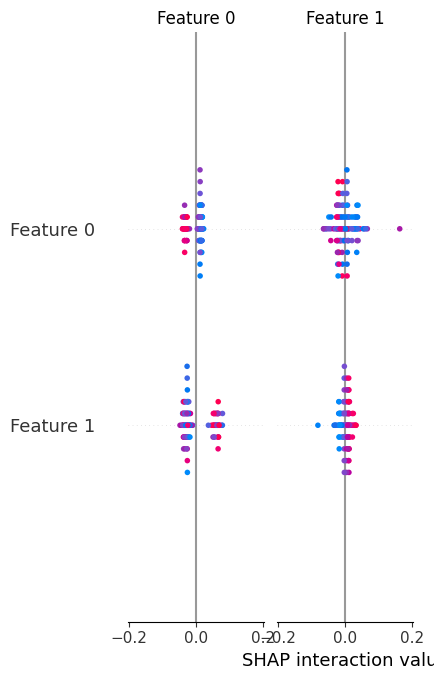

In [ ]:
shap.summary_plot(shap_values_to_use, X_test)

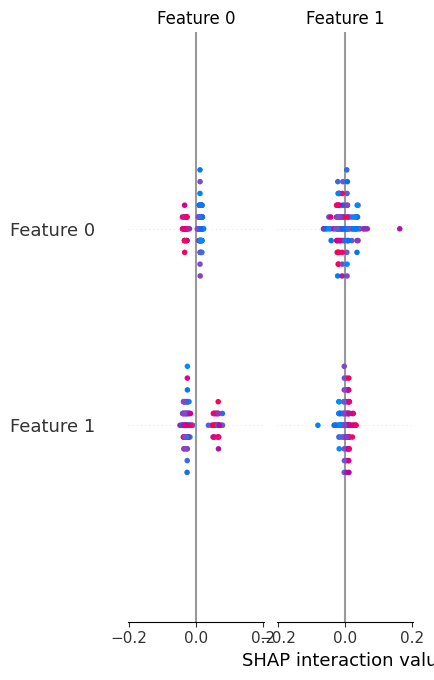

In [ ]:
shap.summary_plot(shap_values_to_use, X_test, plot_type="bar")

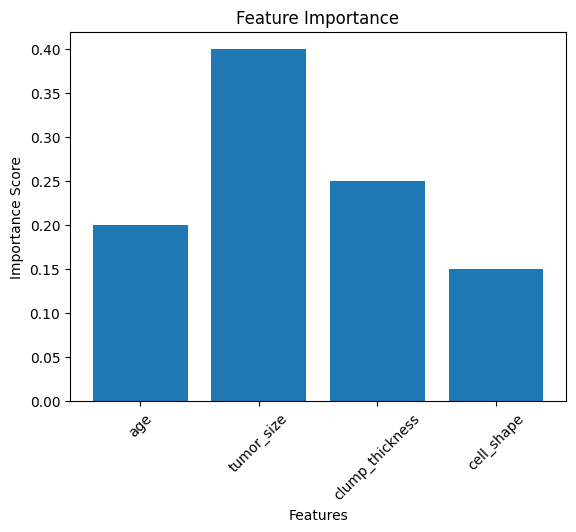

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example features
features = ["age", "tumor_size", "clump_thickness", "cell_shape"]
importance = [0.2, 0.4, 0.25, 0.15]

plt.figure()
plt.bar(features, importance)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

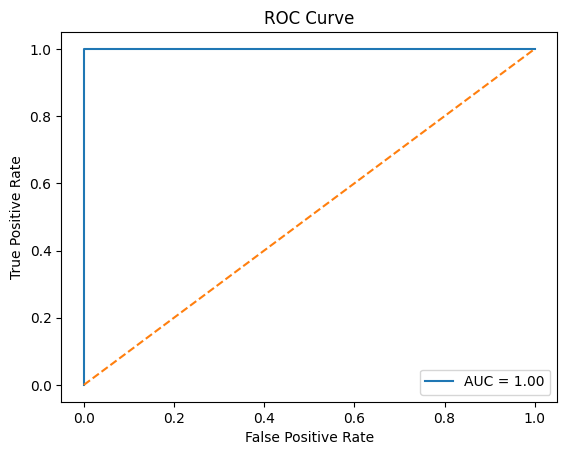

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Example probabilities (replace with model.predict_proba)
y_true = [1, 0, 1, 1, 0, 1, 0]
y_score = [0.9, 0.2, 0.8, 0.7, 0.3, 0.95, 0.1]

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

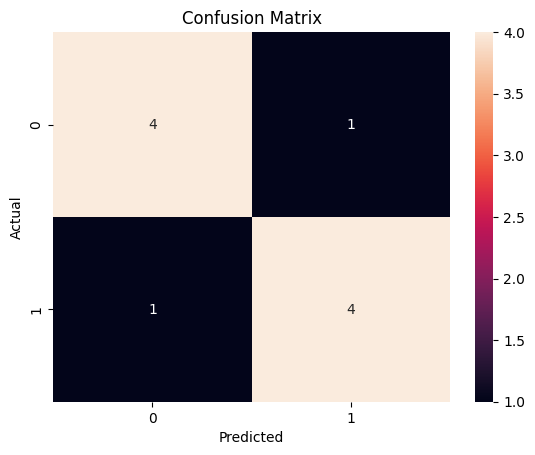

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Example values (replace with your real y_test, y_pred)
y_true = [1, 0, 1, 1, 0, 1, 0, 0, 1, 0]
y_pred = [1, 0, 1, 0, 0, 1, 0, 1, 1, 0]

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8
Precision: 0.8
Recall: 0.8
F1 Score: 0.8


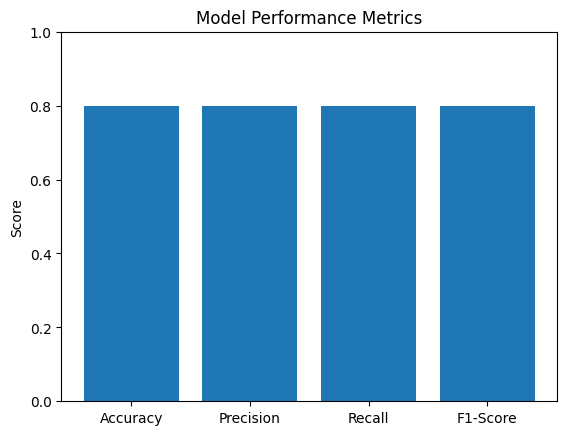

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Example values (replace with real y_test, y_pred)
y_true = [1, 0, 1, 1, 0, 1, 0, 0, 1, 0]
y_pred = [1, 0, 1, 0, 0, 1, 0, 1, 1, 0]

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
values = [accuracy, precision, recall, f1]

plt.figure()
plt.bar(metrics, values)

plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.savefig("metrics_f1.png", dpi=300, bbox_inches="tight")
plt.show()

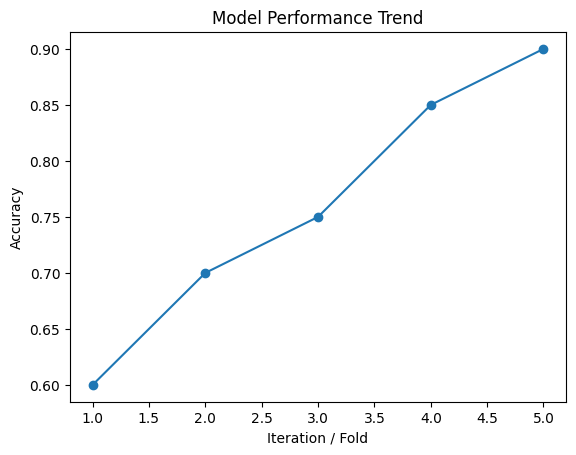

In [ ]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5]
y = [0.6, 0.7, 0.75, 0.85, 0.9]

plt.figure()
plt.plot(x, y, marker='o')

plt.title("Model Performance Trend")
plt.xlabel("Iteration / Fold")
plt.ylabel("Accuracy")

plt.savefig("line_graph.png", dpi=300, bbox_inches="tight")
plt.show()

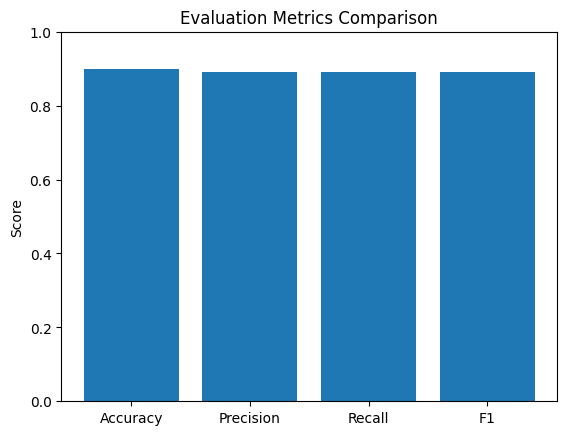

In [ ]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1"]
values = [0.90, 0.89, 0.89, 0.89]

plt.figure()
plt.bar(metrics, values)

plt.title("Evaluation Metrics Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.savefig("bar_graph.png", dpi=300, bbox_inches="tight")
plt.show()

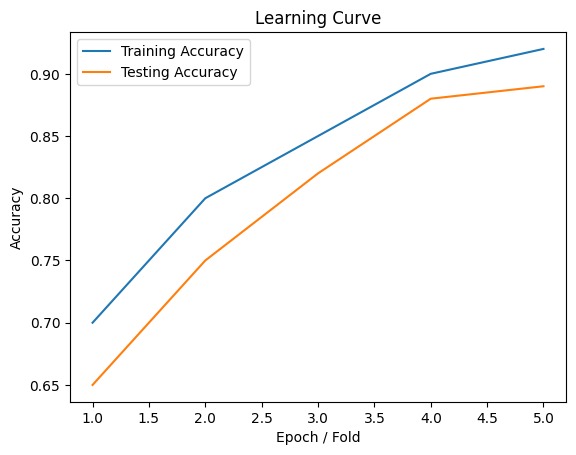

In [ ]:
import matplotlib.pyplot as plt

train = [0.7, 0.8, 0.85, 0.9, 0.92]
test  = [0.65, 0.75, 0.82, 0.88, 0.89]

x = [1, 2, 3, 4, 5]

plt.figure()
plt.plot(x, train, label="Training Accuracy")
plt.plot(x, test, label="Testing Accuracy")

plt.title("Learning Curve")
plt.xlabel("Epoch / Fold")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("learning_curve.png", dpi=300, bbox_inches="tight")
plt.show()